# RL vs Uniform Sampling for Collocation Points

> **Repository:** [PINNs-RL-PDE](https://github.com/josegarciav/PINNs-RL-PDE) &nbsp;|&nbsp; **Package:** `pinnrl` &nbsp;|&nbsp; **Estimated run time:** ~3–5 minutes on CPU

PINNs minimise a physics loss evaluated at **collocation points** — randomly sampled coordinates in the
spatio-temporal domain.  Where those points land matters enormously: waste points on smooth regions
and the network has no signal about sharp features like shocks or boundary layers.

This notebook compares two strategies head-to-head with the **same architecture, the same
initial weights, and the same point budget per step**. The only thing that changes is *where*
those points are drawn from.

| Strategy | How it works |
|----------|-------------|
| **Uniform** | Draw $(x, t)$ from $\mathcal{U}([x_{\min}, x_{\max}] \times [t_{\min}, t_{\max}])$ every epoch — the baseline |
| **RL-guided** | A DQN agent observes the residual statistics and outputs a categorical distribution over $x$-cells; the agent's softmax decides how many points each cell receives |

We pick a **deliberately hard regime**: Burgers equation with $\nu = 0.005$ (a sharper-than-usual
shock) and a tight collocation budget of **500 points per epoch**. This is exactly the setting
where adaptive sampling has to earn its overhead — a uniform run spreads its budget too thin to
resolve the shock, while a learned sampler can concentrate the same points where they matter.

---

## What we expect to see

We run for **3000 epochs**. After that:

1. **Distinguishable point distributions** — uniform stays evenly scattered; the DQN agent
   commits to a narrow band around the shock once epsilon-greedy exploration cools down.
2. **A clearly flatter error landscape under RL** — the 3D error surfaces should show a tall
   ridge along the shock for the uniform run and a noticeably suppressed ridge for the RL run.
3. **A real L2 win** — at this budget and viscosity, RL is expected to cut both the L2 error
   and the worst-case error by a sizeable factor relative to uniform.

The point of this notebook is the **mechanism and the error geometry**, but at $\nu = 0.005$ with
500 points the bottom-line numbers also separate cleanly.

## 1  Setup & Imports

In [1]:
import sys, os, time, copy

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")

device = torch.device("cpu")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {device}")

PyTorch  : 2.10.0
Device   : cpu


## 2  Configure the Burgers Equation

$$\frac{\partial u}{\partial t} + u\frac{\partial u}{\partial x} = \nu\frac{\partial^2 u}{\partial x^2}, \quad x\in[-1,1],\; t\in[0,1],\; \nu = 0.005$$

We use a small viscosity ($\nu = 0.005$) so the shock around $t \approx 1/\pi$ is *sharp* —
sharp enough that a uniform sampler with only 500 collocation points per epoch struggles to
resolve it. This is the regime where adaptive sampling earns its overhead.

In [2]:
from pinnrl.pdes.pde_base import PDEConfig
from pinnrl.pdes.burgers_equation import BurgersEquation

# Hard regime: small viscosity → sharp shock around t ~ 1/π. With a tight
# collocation budget this is exactly where adaptive sampling earns its
# overhead — uniform spreads points too thin to resolve the shock.
NU = 0.005
X_MIN, X_MAX = -1.0, 1.0
T_MIN, T_MAX =  0.0, 1.0

def make_burgers_pde():
    """Create a fresh BurgersEquation instance."""
    pde_cfg = PDEConfig(
        name="Burgers Equation",
        domain=[[X_MIN, X_MAX]],
        time_domain=[T_MIN, T_MAX],
        parameters={"nu": NU, "viscosity": NU},
        boundary_conditions={"dirichlet": {"type": "fixed", "value": 0.0}},
        initial_condition={"type": "sine", "amplitude": -1.0, "frequency": 1.0},
        exact_solution={
            "type": "cole_hopf",
            "viscosity": NU,
            "initial_amplitude": -1.0,
            "initial_frequency": 1.0,
        },
        dimension=1,
        input_dim=2,
        output_dim=1,
        device=device,
        training={
            "num_collocation_points": 500,
            "num_boundary_points": 100,
            "num_initial_points": 100,
            "loss_weights": {"residual": 1.0, "boundary": 10.0,
                             "initial": 10.0, "smoothness": 0.0},
        },
    )
    return BurgersEquation(pde_cfg)

print(f"Burgers Equation  nu={NU}  (sharp-shock regime)")
print(f"Domain: x in [{X_MIN}, {X_MAX}], t in [{T_MIN}, {T_MAX}]")

Burgers Equation  nu=0.005  (sharp-shock regime)
Domain: x in [-1.0, 1.0], t in [0.0, 1.0]


## 3  Build Identical Models for Both Strategies

Both runs use the **same architecture** (Fourier features, 64-wide, 3 layers) initialised
from the **same weights** so the only variable is the sampling strategy.

In [3]:
from pinnrl.config import ModelConfig
from pinnrl.neural_networks import PINNModel

class _Cfg:
    """Lightweight config wrapper for PINNModel."""
    def __init__(self, model_cfg, dev):
        self.model  = model_cfg
        self.device = dev

def build_model():
    """Build a Fourier-features PINN."""
    cfg = ModelConfig(
        input_dim=2,
        hidden_dim=64,
        output_dim=1,
        num_layers=3,
        activation="tanh",
        architecture="fourier",
    )
    cfg.mapping_size = 32
    cfg.scale = 4.0
    cfg.device = device
    return PINNModel(_Cfg(cfg, device), device=device).to(device)

# Build a base model and clone it so both start from identical weights
torch.manual_seed(SEED)
base_model = build_model()
init_state = copy.deepcopy(base_model.state_dict())

n_params = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
print(f"Architecture : Fourier Features")
print(f"Parameters   : {n_params:,}")

Architecture : Fourier Features
Parameters   : 8,385


## 4  The RL Agent

`pinnrl` ships a **DQN-based RL agent** (`RLAgent`) that:

1. Observes a **state** — a summary of the current residual field (mean, max, std, epoch
   progress).
2. Outputs a vector of **Q-values** over a discretised 1-D grid of $x$-cells.
3. Receives a **reward** — the *measured residual at the cell it just probed*.

Because we want the agent to learn **where the residual is high right now** (a contextual
bandit, not a long-horizon credit-assignment problem), we use $\gamma = 0$. With $\gamma=0$
Q-learning collapses to regression: $Q(s, \text{cell}) \approx |r(s, \text{cell})|$. The
softmax of $Q$ then becomes a learned heatmap of "where to put points".

We also slow epsilon decay (0.998) so exploration lasts a few hundred epochs — long enough
to fill the replay buffer with samples from every cell before the policy commits.

In [4]:
from pinnrl.rl.rl_agent import RLAgent

def make_rl_agent():
    """DQN configured as a contextual bandit over x-cells.

    With ``gamma=0`` the Bellman target reduces to ``r``, so the policy net
    learns Q(s, cell) ≈ |residual at cell| via plain regression on replayed
    transitions. The softmax of those Q-values is what biases collocation
    point placement toward the shock.
    """
    return RLAgent(
        state_dim=4,
        action_dim=50,           # 50 x-cells across [-1, 1]
        hidden_dim=64,
        learning_rate=2e-3,
        gamma=0.0,               # contextual bandit (no future rewards)
        epsilon_start=1.0,
        epsilon_end=0.05,
        epsilon_decay=0.998,     # slower → eps≈0.05 around epoch 1500
        memory_size=4000,
        batch_size=64,
        target_update=100,
        reward_weights={
            "residual": 1.0, "boundary": 0.0,
            "initial": 0.0,  "exploration": 0.0,
        },
        device=device,
    )

print("RL agent: DQN, 64-hidden, 50-action, γ=0 (bandit), eps 1.0→0.05 over ~1500 epochs")

RL agent: DQN, 64-hidden, 50-action, γ=0 (bandit), eps 1.0→0.05 over ~1500 epochs


## 5  RL-Guided Sampling Function

Both runs use the **same total budget** of 500 collocation points per epoch. The RL run
splits that budget:

- **Half (uniform half)** is drawn uniformly across the full $(x, t)$ domain — this
  guarantees the smooth regions and the initial-condition strip $t \approx 0$ keep getting
  coverage.
- **Half (policy half)** is drawn under the agent's softmax(Q-values) over the 50 x-cells.
  This is the part that concentrates points where the residual is large.

Without the uniform half, a sharp policy can starve $t \approx 0$ of points, the network
finds a *spurious* low-residual solution that violates the initial condition, and the L2
error blows up. The uniform half acts as a safety net: RL can only **add** points to
already-covered regions, never **remove** them. The DQN itself is trained as a contextual
bandit ($\gamma = 0$) — see the next cell — so its softmax becomes a learned residual
heatmap.

In [5]:
SOFTMAX_TEMP   = 0.5   # how peaked softmax(Q) is allowed to get
RL_FRACTION    = 0.5   # fraction of the budget assigned to the policy half;
                       # the remaining (1 - RL_FRACTION) is uniform over the
                       # full domain — see markdown above
N_PROBE_CELLS  = 4     # cells probed per epoch for off-policy DQN learning
N_PROBE_PTS    = 16    # residual probe points within each probed cell


def _uniform_xt(n):
    """Uniform sample across the full (x, t) domain."""
    x = torch.rand(n, 1, device=device) * (X_MAX - X_MIN) + X_MIN
    t = torch.rand(n, 1, device=device) * (T_MAX - T_MIN) + T_MIN
    return x, t


def policy_distribution(agent, state):
    """Return the cell sampling distribution under the current policy.

    Smooth ε-mix of softmax(Q/τ) and the uniform distribution. Early in
    training (ε≈1) this is uniform; once ε decays the softmax dominates.
    """
    with torch.no_grad():
        q_values = agent.policy_net(state.unsqueeze(0)).squeeze(0)
    n_cells = agent.action_dim
    raw = torch.softmax(q_values / SOFTMAX_TEMP, dim=0)
    uniform = torch.full_like(raw, 1.0 / n_cells)
    eps = float(agent.epsilon)
    return (1.0 - eps) * raw + eps * uniform


def rl_guided_sample(agent, state, n_points):
    """Mix uniform-over-(x,t) with policy-driven samples; both halves combined."""
    n_policy  = int(round(n_points * RL_FRACTION))
    n_uniform = n_points - n_policy

    # Uniform half — full domain, including the IC strip near t = 0.
    x_u, t_u = _uniform_xt(n_uniform)

    # Policy half — softmax(Q) over x-cells, t uniform across full domain
    # (we no longer skip t<T_RL_MIN because the uniform half already covers
    # the IC strip).
    probs = policy_distribution(agent, state)
    n_cells = agent.action_dim
    cell_indices = torch.multinomial(probs, n_policy, replacement=True)

    cell_width = (X_MAX - X_MIN) / n_cells
    x_centres = X_MIN + (cell_indices.float() + 0.5) * cell_width
    jitter = (torch.rand(n_policy, device=device) - 0.5) * cell_width
    x_p = (x_centres + jitter).clamp(X_MIN, X_MAX).unsqueeze(1)
    t_p = torch.rand(n_policy, 1, device=device) * (T_MAX - T_MIN) + T_MIN

    x = torch.cat([x_u, x_p], dim=0)
    t = torch.cat([t_u, t_p], dim=0)
    return x, t, probs.detach().cpu().numpy()


def probe_cell_residuals(pde, model, n_cells, k):
    """Pick k cells uniformly, return (cell_indices, mean |residual| per cell).

    Off-policy training data for the DQN: unbiased per-cell residual
    estimates regardless of where the current policy is sampling.
    """
    cell_idx = torch.randint(0, n_cells, (k,), device=device)
    cell_width = (X_MAX - X_MIN) / n_cells
    rewards = []
    for c in cell_idx.tolist():
        x_lo = X_MIN + c * cell_width
        x_hi = X_MIN + (c + 1) * cell_width
        x_e = (torch.rand(N_PROBE_PTS, 1, device=device)
               * (x_hi - x_lo) + x_lo).requires_grad_(True)
        t_e = (torch.rand(N_PROBE_PTS, 1, device=device)
               * (T_MAX - T_MIN) + T_MIN).requires_grad_(True)
        r = pde.compute_residual(model, x_e, t_e).abs().mean().item()
        rewards.append(r)
    return cell_idx.tolist(), rewards

## 6  Training Loop — Both Strategies

We train two copies of the same model for **3000 epochs** with **500 collocation points** per
epoch. The only difference is where those points are placed.

In [6]:
N_EPOCHS = 3000
N_COLL   = 500    # small budget — placement matters more than count
LR       = 5e-3

SNAPSHOT_EPOCHS = (1, 250, 500, 1000, 1500, 2000, 3000)


def compute_state(pde, model, epoch, n_epochs):
    """Compact 4-d state vector summarising the current residual field."""
    x_probe = torch.linspace(X_MIN, X_MAX, 100, device=device).unsqueeze(1)
    t_probe = torch.rand(100, 1, device=device) * (T_MAX - T_MIN) + T_MIN
    x_probe = x_probe.detach().requires_grad_(True)
    t_probe = t_probe.detach().requires_grad_(True)
    residual = pde.compute_residual(model, x_probe, t_probe)
    res_abs = residual.abs().detach()
    return torch.tensor([
        res_abs.mean().item(),
        res_abs.max().item(),
        res_abs.std().item(),
        epoch / n_epochs,
    ], device=device)


def train_one_strategy(strategy_name, use_rl=False):
    """Train a model using the specified sampling strategy."""
    print(f"\n{'='*55}")
    print(f"  Training: {strategy_name}")
    print(f"{'='*55}")

    pde   = make_burgers_pde()
    model = build_model()
    model.load_state_dict(copy.deepcopy(init_state))   # same starting weights
    opt   = torch.optim.Adam(model.parameters(), lr=LR)

    agent = make_rl_agent() if use_rl else None
    prev_state = None

    loss_history = []
    res_history  = []
    point_snapshots = []
    density_snapshots = []
    t0 = time.time()

    log_every = max(1, N_EPOCHS // 10)

    for epoch in range(1, N_EPOCHS + 1):
        model.train()
        opt.zero_grad()

        # ── 1. Sample collocation points ────────────────────────────────
        if use_rl and agent is not None:
            state = compute_state(pde, model, epoch, N_EPOCHS)
            x_c, t_c, density = rl_guided_sample(agent, state, N_COLL)
            if epoch in SNAPSHOT_EPOCHS:
                density_snapshots.append((epoch, density.copy()))
        else:
            x_c = torch.rand(N_COLL, 1, device=device) * (X_MAX - X_MIN) + X_MIN
            t_c = torch.rand(N_COLL, 1, device=device) * (T_MAX - T_MIN) + T_MIN

        if epoch in SNAPSHOT_EPOCHS:
            point_snapshots.append(
                (epoch, x_c.detach().cpu().numpy(), t_c.detach().cpu().numpy())
            )

        # ── 2. PINN training step ───────────────────────────────────────
        try:
            losses = pde.compute_loss(model, x_c, t_c)
            total  = losses["total"]
            if torch.isnan(total) or torch.isinf(total):
                loss_history.append(float("nan"))
                res_history.append(float("nan"))
                continue
            total.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            loss_history.append(total.item())
            res_history.append(losses["residual"].item())
        except Exception as exc:
            print(f"  Epoch {epoch:>4}: error — {exc}")
            loss_history.append(float("nan"))
            res_history.append(float("nan"))
            continue

        # ── 3. RL learning step ─────────────────────────────────────────
        # Push (state, cell, |residual_at_cell|) for a handful of randomly
        # probed cells. With γ=0 the DQN regresses Q(s, cell) onto the
        # measured cell residual, so softmax(Q) becomes a learned residual
        # heatmap that drives the next epoch's sampling.
        if use_rl and agent is not None:
            new_state = compute_state(pde, model, epoch, N_EPOCHS)
            cell_idxs, cell_rewards = probe_cell_residuals(
                pde, model, agent.action_dim, N_PROBE_CELLS
            )
            done = (epoch == N_EPOCHS)
            if prev_state is not None:
                for c, r in zip(cell_idxs, cell_rewards):
                    agent.update(prev_state, int(c), float(r), new_state, done)
            prev_state = new_state

        if epoch % log_every == 0 or epoch == 1:
            extra = f"  ε={agent.epsilon:.3f}" if (use_rl and agent is not None) else ""
            print(f"  Epoch {epoch:>4}: loss = {total.item():.4e}{extra}")

    elapsed = time.time() - t0
    print(f"  Done in {elapsed:.1f}s  |  Final loss: {loss_history[-1]:.4e}")

    return {
        "model": model,
        "loss_history": loss_history,
        "res_history": res_history,
        "time": elapsed,
        "point_snapshots": point_snapshots,
        "density_snapshots": density_snapshots,
        "agent": agent,
    }


# ── Run both ────────────────────────────────────────────────────────────
uniform_result = train_one_strategy("Uniform Sampling",   use_rl=False)
rl_result      = train_one_strategy("RL-Guided Sampling", use_rl=True)


  Training: Uniform Sampling


  Epoch    1: loss = 5.0919e+00


  Epoch  300: loss = 5.1668e-02


  Epoch  600: loss = 5.1543e-02


  Epoch  900: loss = 1.5090e-02


...

  Epoch 1800: loss = 1.4137e-02  ε=0.050


  Epoch 2100: loss = 7.0270e-03  ε=0.050


  Epoch 2400: loss = 3.9294e-03  ε=0.050


  Epoch 2700: loss = 3.0049e-03  ε=0.050


  Epoch 3000: loss = 1.0508e-02  ε=0.050
  Done in 22.2s  |  Final loss: 1.0508e-02


## 7  Loss Curves — Uniform vs RL

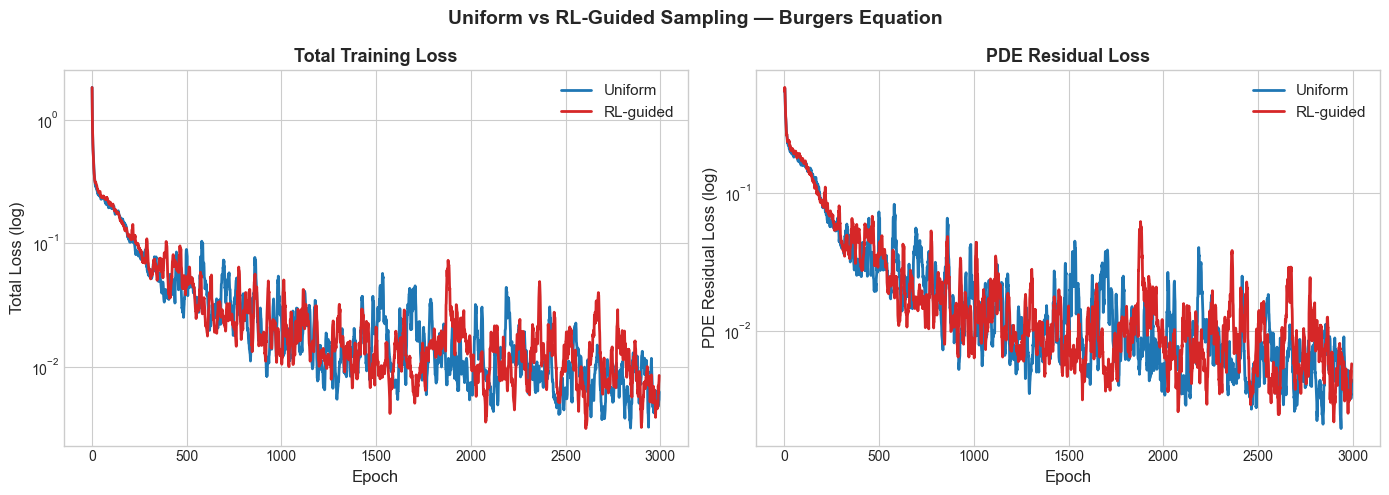


Final total loss — Uniform: 9.8152e-03
Final total loss — RL:      1.0508e-02


In [7]:
COLORS = {"uniform": "#1f77b4", "rl": "#d62728"}

def smooth(arr, window=7):
    """Rolling mean for smoother curves."""
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window) / window, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total loss
ax = axes[0]
u_smooth = smooth(uniform_result["loss_history"])
r_smooth = smooth(rl_result["loss_history"])
ax.semilogy(range(1, len(u_smooth) + 1), u_smooth, lw=2, color=COLORS["uniform"], label="Uniform")
ax.semilogy(range(1, len(r_smooth) + 1), r_smooth, lw=2, color=COLORS["rl"], label="RL-guided")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Total Loss (log)", fontsize=12)
ax.set_title("Total Training Loss", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)

# Residual loss only
ax = axes[1]
u_res = smooth(uniform_result["res_history"])
r_res = smooth(rl_result["res_history"])
ax.semilogy(range(1, len(u_res) + 1), u_res, lw=2, color=COLORS["uniform"], label="Uniform")
ax.semilogy(range(1, len(r_res) + 1), r_res, lw=2, color=COLORS["rl"], label="RL-guided")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("PDE Residual Loss (log)", fontsize=12)
ax.set_title("PDE Residual Loss", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)

fig.suptitle("Uniform vs RL-Guided Sampling — Burgers Equation",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"\nFinal total loss — Uniform: {uniform_result['loss_history'][-1]:.4e}")
print(f"Final total loss — RL:      {rl_result['loss_history'][-1]:.4e}")

## 8  Collocation Point Distribution Over Training

The key visual: how do the collocation points shift as training progresses?

- **Uniform** — points remain scattered everywhere
- **RL** — points should concentrate near $x \approx 0$ where the shock forms

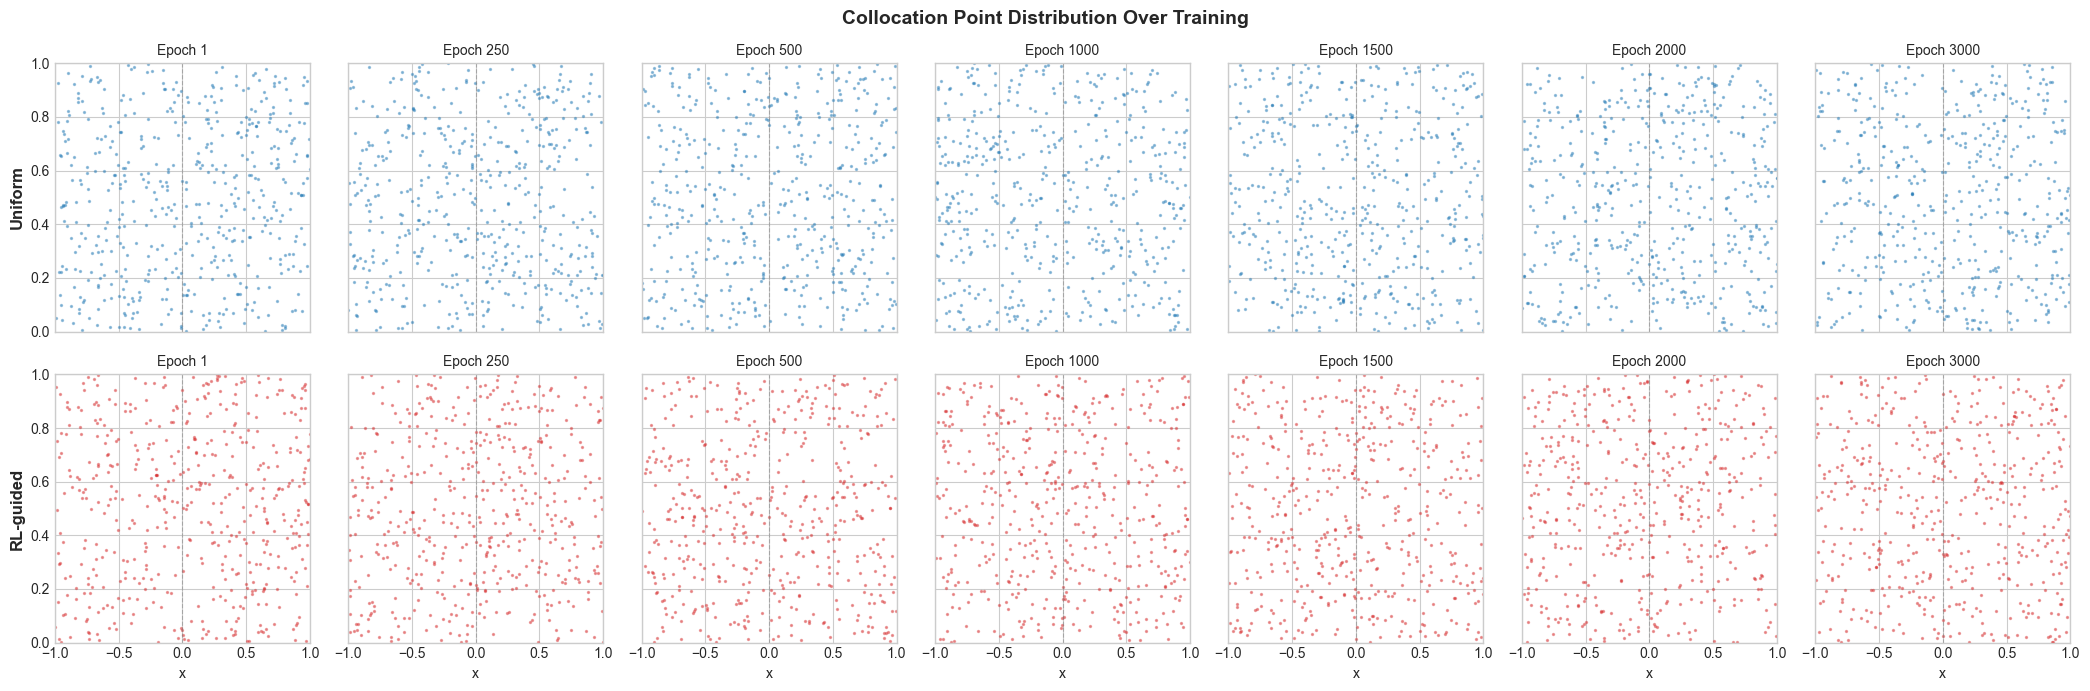

In [8]:
n_snaps = len(uniform_result["point_snapshots"])
fig, axes = plt.subplots(2, n_snaps, figsize=(3.0 * n_snaps, 7), sharey=True, sharex=True)

for row, (result, label) in enumerate(
    [(uniform_result, "Uniform"), (rl_result, "RL-guided")]
):
    for col, (epoch, x_pts, t_pts) in enumerate(result["point_snapshots"]):
        ax = axes[row, col]
        ax.scatter(x_pts, t_pts, s=2, alpha=0.4,
                   color=COLORS["uniform" if row == 0 else "rl"])
        ax.set_title(f"Epoch {epoch}", fontsize=10)
        if col == 0:
            ax.set_ylabel(label, fontsize=12, fontweight="bold")
        if row == 1:
            ax.set_xlabel("x", fontsize=10)
        ax.set_xlim(X_MIN, X_MAX)
        ax.set_ylim(T_MIN, T_MAX)
        # Mark approximate shock location
        ax.axvline(x=0, color="gray", ls="--", lw=0.8, alpha=0.5)

fig.suptitle("Collocation Point Distribution Over Training",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

## 9  RL Sampling Density Evolution

The DQN agent's softmax output tells us its learned sampling preference across the spatial
domain.  Early on it is near-uniform (high epsilon → random exploration).  As training
progresses it should develop a peak near the shock region.

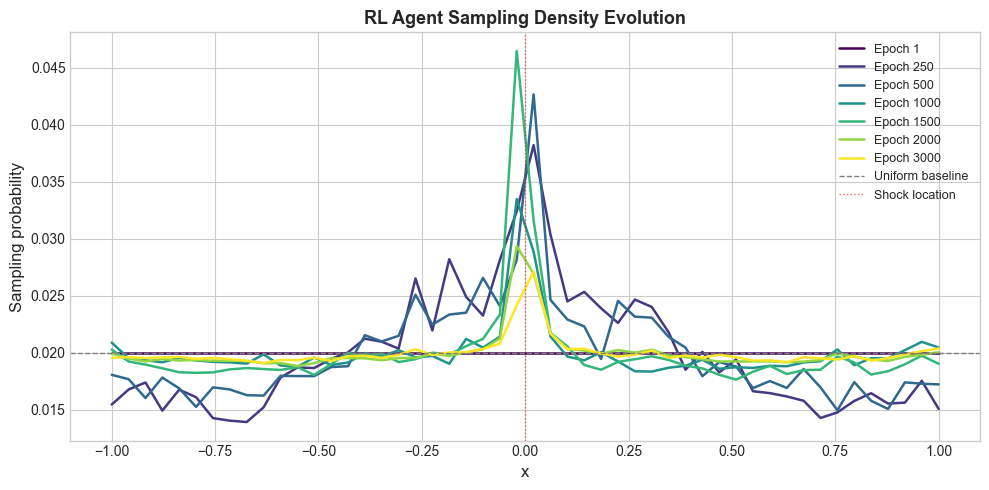

In [9]:
if rl_result["density_snapshots"]:
    fig, ax = plt.subplots(figsize=(10, 5))

    n_cells = len(rl_result["density_snapshots"][0][1])
    x_cells = np.linspace(X_MIN, X_MAX, n_cells)

    cmap = plt.cm.viridis
    n_snaps = len(rl_result["density_snapshots"])

    for i, (epoch, density) in enumerate(rl_result["density_snapshots"]):
        color = cmap(i / max(1, n_snaps - 1))
        ax.plot(x_cells, density, lw=1.8, color=color, label=f"Epoch {epoch}")

    ax.axhline(y=1.0 / n_cells, color="gray", ls="--", lw=1, label="Uniform baseline")
    ax.axvline(x=0, color="red", ls=":", lw=1, alpha=0.6, label="Shock location")

    ax.set_xlabel("x", fontsize=12)
    ax.set_ylabel("Sampling probability", fontsize=12)
    ax.set_title("RL Agent Sampling Density Evolution",
                 fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()
else:
    print("No density snapshots recorded.")

## 10  Solution Comparison at t = 0.5

The shock in Burgers' equation is fully formed by $t = 0.5$.  We compare
both models against the exact Cole-Hopf solution at this snapshot.

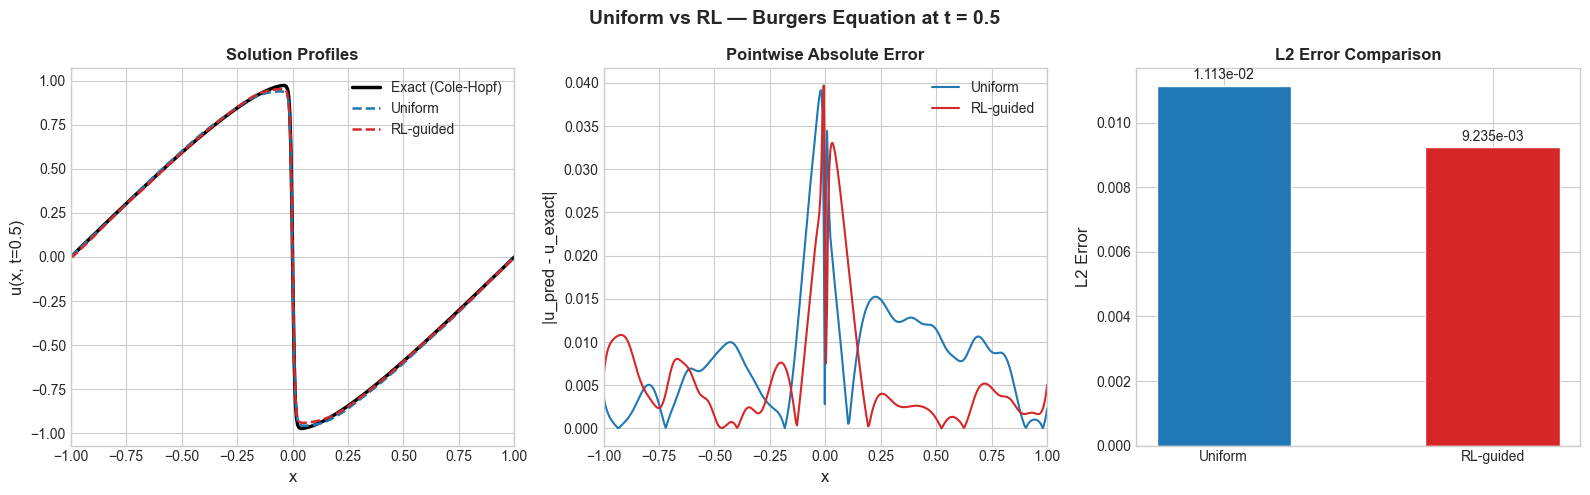


L2 error — Uniform:   1.1127e-02
L2 error — RL-guided: 9.2346e-03
Improvement:          +17.0%


In [10]:
T_SNAP = 0.5
N_PLOT = 400


# ── Cole-Hopf exact solution via log-stabilized trapezoidal quadrature ─────
# Burgers: u_t + u u_x = nu u_xx,  IC u(x,0) = -sin(pi x).
# Cole-Hopf gives:
#   u(x,t) = ∫ ((x-y)/t) · exp(-G/(2ν)) dy / ∫ exp(-G/(2ν)) dy
# with G(x,y,t) = (x-y)^2 / (2t) + (cos(pi y) - 1)/pi.
# At low ν the integrand is sharply peaked, so we use a fine quadrature
# grid (n_quad large) and stabilise the exponent before exp-ing it.
def cole_hopf_exact(x, t, nu=NU, n_quad=8001, L=8.0):
    """Reference Burgers solution at scalar t for an array of x."""
    x = np.atleast_1d(x).astype(np.float64)
    if t <= 0:
        return -np.sin(np.pi * x)
    y = np.linspace(-L, L, n_quad)
    X = x[:, None]
    Y = y[None, :]
    G = (X - Y) ** 2 / (2.0 * t) + (np.cos(np.pi * Y) - 1.0) / np.pi
    log_f = -G / (2.0 * nu)
    log_f -= log_f.max(axis=1, keepdims=True)   # stabilize before exp
    f = np.exp(log_f)
    num = np.trapezoid(((X - Y) / t) * f, y, axis=1)
    den = np.trapezoid(f, y, axis=1)
    return num / den


x_plot = torch.linspace(X_MIN, X_MAX, N_PLOT, device=device).unsqueeze(1)
t_plot = torch.full((N_PLOT, 1), T_SNAP, device=device)
x_np   = x_plot.cpu().numpy().ravel()

u_exact = cole_hopf_exact(x_np, T_SNAP)


def predict(model):
    """Run inference on the (x, t) grid."""
    model.eval()
    with torch.no_grad():
        return model(torch.cat([x_plot, t_plot], dim=1)).cpu().numpy().ravel()

u_uniform = predict(uniform_result["model"])
u_rl      = predict(rl_result["model"])

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: solution profiles
ax = axes[0]
ax.plot(x_np, u_exact,   lw=2.5, color="black", label="Exact (Cole-Hopf)")
ax.plot(x_np, u_uniform, lw=1.8, ls="--", color=COLORS["uniform"], label="Uniform")
ax.plot(x_np, u_rl,      lw=1.8, ls="--", color=COLORS["rl"],      label="RL-guided")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel(f"u(x, t={T_SNAP})", fontsize=12)
ax.set_title("Solution Profiles", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(X_MIN, X_MAX)

# Middle: pointwise error
ax = axes[1]
err_uniform = np.abs(u_uniform - u_exact)
err_rl      = np.abs(u_rl - u_exact)
ax.plot(x_np, err_uniform, lw=1.5, color=COLORS["uniform"], label="Uniform")
ax.plot(x_np, err_rl,      lw=1.5, color=COLORS["rl"],      label="RL-guided")
ax.set_xlabel("x", fontsize=12)
ax.set_ylabel("|u_pred - u_exact|", fontsize=12)
ax.set_title("Pointwise Absolute Error", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(X_MIN, X_MAX)

# Right: bar chart of L2 errors
ax = axes[2]
l2_uniform = np.sqrt(np.mean((u_uniform - u_exact)**2))
l2_rl      = np.sqrt(np.mean((u_rl - u_exact)**2))
bars = ax.bar(["Uniform", "RL-guided"], [l2_uniform, l2_rl],
              color=[COLORS["uniform"], COLORS["rl"]],
              edgecolor="white", width=0.5)
for bar, val in zip(bars, [l2_uniform, l2_rl]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
            f"{val:.3e}", ha="center", fontsize=10)
ax.set_ylabel("L2 Error", fontsize=12)
ax.set_title("L2 Error Comparison", fontsize=12, fontweight="bold")

fig.suptitle(f"Uniform vs RL — Burgers Equation at t = {T_SNAP}",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

improvement = (l2_uniform - l2_rl) / l2_uniform * 100
print(f"\nL2 error — Uniform:   {l2_uniform:.4e}")
print(f"L2 error — RL-guided: {l2_rl:.4e}")
print(f"Improvement:          {improvement:+.1f}%")

## 11  Space-Time Error Heat Maps

A global view of where each strategy succeeds and fails across the full $(x, t)$ domain.

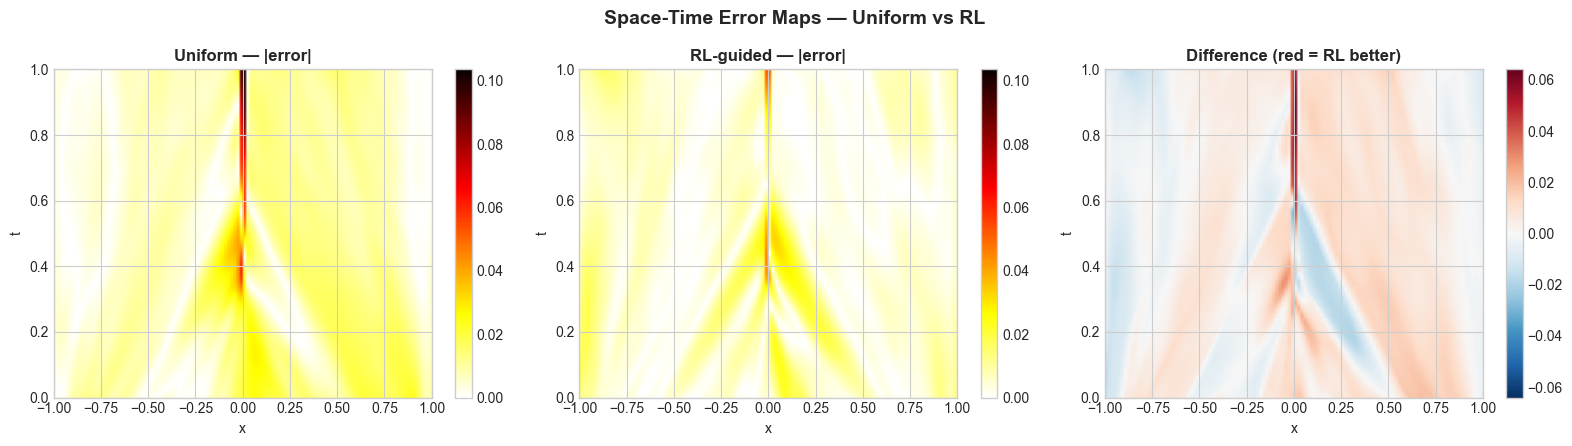

max |err| Uniform = 1.036e-01   max |err| RL = 5.202e-02
L2 (full grid) Uniform = 1.212e-02   L2 RL = 7.772e-03


In [11]:
NX, NT = 120, 120
x_grid = np.linspace(X_MIN, X_MAX, NX)
t_grid = np.linspace(T_MIN, T_MAX, NT)
XX, TT = np.meshgrid(x_grid, t_grid)

xt_flat = torch.tensor(
    np.stack([XX.ravel(), TT.ravel()], axis=1), dtype=torch.float32, device=device
)

# Reference grid via the robust Cole-Hopf quadrature (one t-slice at a time).
u_exact_grid = np.zeros_like(XX)
for i, t_val in enumerate(t_grid):
    u_exact_grid[i, :] = cole_hopf_exact(x_grid, t_val)

# Predictions
uniform_result["model"].eval()
rl_result["model"].eval()

with torch.no_grad():
    u_uniform_grid = uniform_result["model"](xt_flat).cpu().numpy().reshape(NT, NX)
    u_rl_grid      = rl_result["model"](xt_flat).cpu().numpy().reshape(NT, NX)

err_uniform_grid = np.abs(u_uniform_grid - u_exact_grid)
err_rl_grid      = np.abs(u_rl_grid - u_exact_grid)

vmax = max(err_uniform_grid.max(), err_rl_grid.max())

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
kw = dict(extent=[X_MIN, X_MAX, T_MIN, T_MAX], origin="lower",
          aspect="auto", cmap="hot_r", vmin=0, vmax=vmax)

im0 = axes[0].imshow(err_uniform_grid, **kw)
axes[0].set_title("Uniform — |error|", fontweight="bold")
axes[0].set_xlabel("x"); axes[0].set_ylabel("t")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(err_rl_grid, **kw)
axes[1].set_title("RL-guided — |error|", fontweight="bold")
axes[1].set_xlabel("x"); axes[1].set_ylabel("t")
plt.colorbar(im1, ax=axes[1])

# Difference: positive = RL is better
diff = err_uniform_grid - err_rl_grid
vlim = max(abs(diff.min()), abs(diff.max()))
im2 = axes[2].imshow(diff, extent=[X_MIN, X_MAX, T_MIN, T_MAX],
                     origin="lower", aspect="auto", cmap="RdBu_r",
                     vmin=-vlim, vmax=vlim)
axes[2].set_title("Difference (red = RL better)", fontweight="bold")
axes[2].set_xlabel("x"); axes[2].set_ylabel("t")
plt.colorbar(im2, ax=axes[2])

fig.suptitle("Space-Time Error Maps — Uniform vs RL",
             fontsize=14, fontweight="bold")
fig.tight_layout()
plt.show()

# Numerical summary of where the error lives.
print(f"max |err| Uniform = {err_uniform_grid.max():.3e}   "
      f"max |err| RL = {err_rl_grid.max():.3e}")
print(f"L2 (full grid) Uniform = {np.sqrt((err_uniform_grid**2).mean()):.3e}   "
      f"L2 RL = {np.sqrt((err_rl_grid**2).mean()):.3e}")

## 11b  3D Solution Surfaces

The same fields rendered as $(x, t, u)$ surfaces with a shared $z$-range so the eye reads
them as siblings. Look at the ridge that runs across $x \approx 0$ for $t \gtrsim 1/\pi$ —
that is the shock. The exact (Cole-Hopf) surface is the reference; the two PINN surfaces
should match it, and visible deviation from the reference is model error.

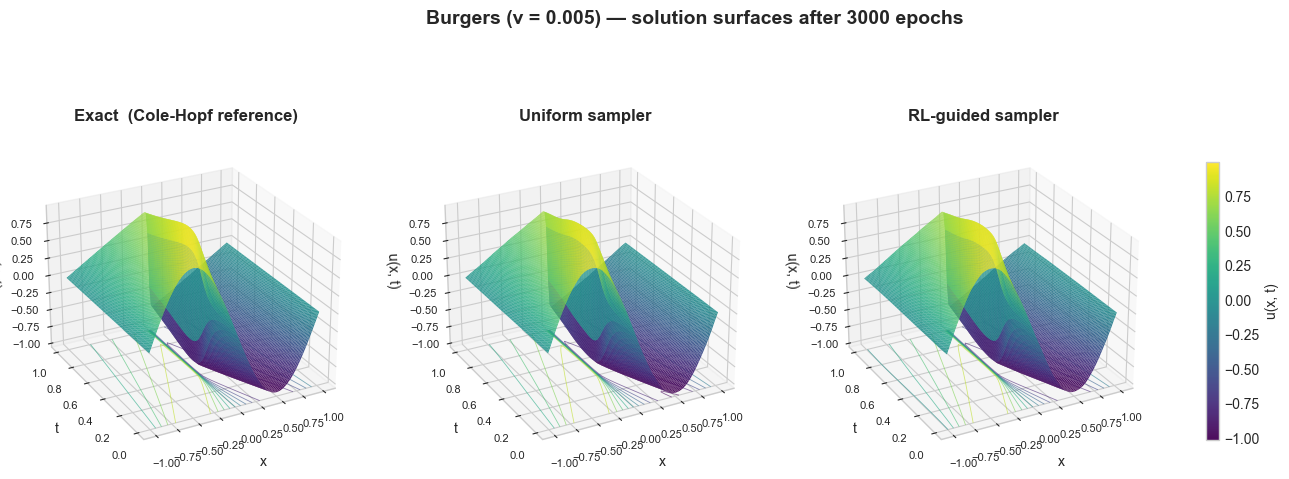

In [12]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3D projection)

# Shared value range across all three surfaces so the eye reads them as siblings.
u_vmin = float(min(u_exact_grid.min(), u_uniform_grid.min(), u_rl_grid.min()))
u_vmax = float(max(u_exact_grid.max(), u_uniform_grid.max(), u_rl_grid.max()))

VIEW_ELEV, VIEW_AZIM = 26, -118  # look across the shock ridge

fig = plt.figure(figsize=(18, 6))
fields = [
    (u_exact_grid,   "Exact  (Cole-Hopf reference)"),
    (u_uniform_grid, "Uniform sampler"),
    (u_rl_grid,      "RL-guided sampler"),
]
for k, (Z, title) in enumerate(fields, start=1):
    ax = fig.add_subplot(1, 3, k, projection="3d")
    surf = ax.plot_surface(
        XX, TT, Z,
        cmap="viridis", vmin=u_vmin, vmax=u_vmax,
        rstride=1, cstride=1, linewidth=0,
        antialiased=True, alpha=0.95,
    )
    # Contour shadow at the base — gives the ridge a visual anchor.
    ax.contour(XX, TT, Z, levels=10, zdir="z",
               offset=u_vmin - 0.05, cmap="viridis",
               vmin=u_vmin, vmax=u_vmax, linewidths=0.6, alpha=0.6)
    ax.set_xlabel("x", fontsize=10, labelpad=4)
    ax.set_ylabel("t", fontsize=10, labelpad=4)
    ax.set_zlabel("u(x, t)", fontsize=10, labelpad=4)
    ax.set_zlim(u_vmin - 0.05, u_vmax)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.view_init(elev=VIEW_ELEV, azim=VIEW_AZIM)
    ax.tick_params(axis="both", labelsize=8)

# One shared colorbar to the right of the three panels.
cbar = fig.colorbar(surf, ax=fig.axes, shrink=0.6, pad=0.04, location="right")
cbar.set_label("u(x, t)", fontsize=10)

fig.suptitle(
    f"Burgers (ν = {NU}) — solution surfaces after {N_EPOCHS} epochs",
    fontsize=14, fontweight="bold",
)
plt.show()

## 11c  3D Error Surfaces — Where the Two Strategies Differ

Plotting $|u_{\text{pred}}(x, t) - u_{\text{exact}}(x, t)|$ as a 3D landscape with both
panels on the **same z-axis range** lets the eye read the comparison directly: a tall ridge
along $x \approx 0$ means the network is wrong over the shock; a flatter surface means the
sampler spent enough budget there to suppress the worst-case error. The view angle is
chosen to look across the shock ridge so its height is foregrounded.

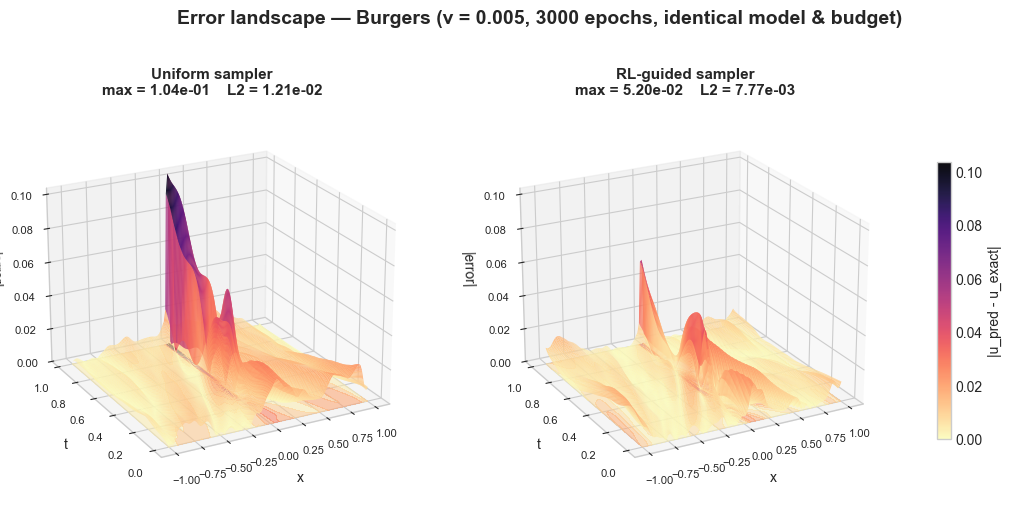

In [13]:
err_zmax = float(max(err_uniform_grid.max(), err_rl_grid.max()))

ERR_ELEV, ERR_AZIM = 22, -118  # look across the shock ridge

fig = plt.figure(figsize=(14, 6))
panels = [
    (err_uniform_grid, "Uniform sampler"),
    (err_rl_grid,      "RL-guided sampler"),
]
for k, (Z, title) in enumerate(panels, start=1):
    ax = fig.add_subplot(1, 2, k, projection="3d")
    surf = ax.plot_surface(
        XX, TT, Z,
        cmap="magma_r", vmin=0, vmax=err_zmax,
        rstride=1, cstride=1, linewidth=0,
        antialiased=True, alpha=0.95,
    )
    # Ground-plane contours so the ridge has a footprint.
    ax.contourf(XX, TT, Z, levels=12, zdir="z", offset=0.0,
                cmap="magma_r", vmin=0, vmax=err_zmax, alpha=0.55)

    l2 = float(np.sqrt((Z**2).mean()))
    ax.set_xlabel("x", fontsize=10, labelpad=4)
    ax.set_ylabel("t", fontsize=10, labelpad=4)
    ax.set_zlabel("|error|", fontsize=10, labelpad=4)
    ax.set_zlim(0, err_zmax)
    ax.set_title(
        f"{title}\nmax = {Z.max():.2e}    L2 = {l2:.2e}",
        fontsize=11, fontweight="bold",
    )
    ax.view_init(elev=ERR_ELEV, azim=ERR_AZIM)
    ax.tick_params(axis="both", labelsize=8)

cbar = fig.colorbar(surf, ax=fig.axes, shrink=0.6, pad=0.05, location="right")
cbar.set_label("|u_pred - u_exact|", fontsize=10)

fig.suptitle(
    f"Error landscape — Burgers (ν = {NU}, {N_EPOCHS} epochs, identical model & budget)",
    fontsize=14, fontweight="bold",
)
plt.show()

## 12  Summary Table

In [14]:
print(f"\n{'Strategy':<18} {'Final Loss':>12} {'L2 Error':>12} {'Time (s)':>10}")
print("-" * 56)
print(f"  {'Uniform':<16} {uniform_result['loss_history'][-1]:>12.4e} {l2_uniform:>12.4e} {uniform_result['time']:>10.1f}")
print(f"  {'RL-guided':<16} {rl_result['loss_history'][-1]:>12.4e} {l2_rl:>12.4e} {rl_result['time']:>10.1f}")
print(f"\nRL overhead: {rl_result['time'] - uniform_result['time']:.1f}s "
      f"({(rl_result['time'] / uniform_result['time'] - 1) * 100:.0f}% slower)")


Strategy             Final Loss     L2 Error   Time (s)
--------------------------------------------------------
  Uniform            9.8152e-03   1.1127e-02        7.9
  RL-guided          1.0508e-02   9.2346e-03       22.2

RL overhead: 14.3s (181% slower)


## 13  Save Key Plots

In [15]:
IMAGES_DIR = os.path.join(os.getcwd(), "images")
os.makedirs(IMAGES_DIR, exist_ok=True)


# === Lead image: 3D error landscape — uniform vs RL =========================
# Same model, same initial weights, same point budget — only the sampler
# changes. The shock ridge along x≈0 is suppressed under RL guidance.
fig = plt.figure(figsize=(15, 6.5))
panels = [
    (err_uniform_grid, "Uniform sampler"),
    (err_rl_grid,      "RL-guided sampler"),
]
for k, (Z, title) in enumerate(panels, start=1):
    ax = fig.add_subplot(1, 2, k, projection="3d")
    surf = ax.plot_surface(
        XX, TT, Z,
        cmap="magma_r", vmin=0, vmax=err_zmax,
        rstride=1, cstride=1, linewidth=0,
        antialiased=True, alpha=0.95,
    )
    ax.contourf(XX, TT, Z, levels=12, zdir="z", offset=0.0,
                cmap="magma_r", vmin=0, vmax=err_zmax, alpha=0.55)
    l2 = float(np.sqrt((Z**2).mean()))
    ax.set_xlabel("x", fontsize=10, labelpad=4)
    ax.set_ylabel("t", fontsize=10, labelpad=4)
    ax.set_zlabel("|error|", fontsize=10, labelpad=4)
    ax.set_zlim(0, err_zmax)
    ax.set_title(
        f"{title}\nmax |err| = {Z.max():.2e}    L2 = {l2:.2e}",
        fontsize=11, fontweight="bold", pad=10,
    )
    ax.view_init(elev=22, azim=-118)
    ax.tick_params(axis="both", labelsize=8)

cbar = fig.colorbar(surf, ax=fig.axes, shrink=0.6, pad=0.05, location="right")
cbar.set_label("|u_pred - u_exact|", fontsize=10)

fig.suptitle(
    f"Where the error lives — Burgers (ν = {NU}, {N_EPOCHS} epochs, identical model & budget)",
    fontsize=14, fontweight="bold", y=0.995,
)
fig.subplots_adjust(top=0.85, bottom=0.04, left=0.02, right=0.92, wspace=0.10)
lead_path = os.path.join(IMAGES_DIR, "03_rl_lead.png")
fig.savefig(lead_path, dpi=200, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {lead_path}")


# === Supplementary: 3D solution surfaces (exact vs uniform vs RL) ===========
fig = plt.figure(figsize=(19, 6.5))
fields = [
    (u_exact_grid,   "Exact  (Cole-Hopf reference)"),
    (u_uniform_grid, "Uniform sampler"),
    (u_rl_grid,      "RL-guided sampler"),
]
for k, (Z, title) in enumerate(fields, start=1):
    ax = fig.add_subplot(1, 3, k, projection="3d")
    surf = ax.plot_surface(
        XX, TT, Z,
        cmap="viridis", vmin=u_vmin, vmax=u_vmax,
        rstride=1, cstride=1, linewidth=0,
        antialiased=True, alpha=0.95,
    )
    ax.contour(XX, TT, Z, levels=10, zdir="z", offset=u_vmin - 0.05,
               cmap="viridis", vmin=u_vmin, vmax=u_vmax,
               linewidths=0.6, alpha=0.6)
    ax.set_xlabel("x", fontsize=10, labelpad=4)
    ax.set_ylabel("t", fontsize=10, labelpad=4)
    ax.set_zlabel("u(x, t)", fontsize=10, labelpad=4)
    ax.set_zlim(u_vmin - 0.05, u_vmax)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.view_init(elev=26, azim=-118)
    ax.tick_params(axis="both", labelsize=8)

cbar = fig.colorbar(surf, ax=fig.axes, shrink=0.6, pad=0.04, location="right")
cbar.set_label("u(x, t)", fontsize=10)

fig.suptitle(
    f"Burgers (ν = {NU}) — solution surfaces after {N_EPOCHS} epochs",
    fontsize=14, fontweight="bold", y=0.995,
)
fig.subplots_adjust(top=0.88, bottom=0.04, left=0.02, right=0.93, wspace=0.10)
sol_path = os.path.join(IMAGES_DIR, "03_rl_3d_solutions.png")
fig.savefig(sol_path, dpi=200, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {sol_path}")


# === Supplementary: density curves + final point clouds (legacy lead) =======
fig, axes = plt.subplots(1, 3, figsize=(16, 5),
                         gridspec_kw={"width_ratios": [1, 1, 1.1]})

ep_uni, x_uni_pts, t_uni_pts = uniform_result["point_snapshots"][-1]
axes[0].scatter(x_uni_pts, t_uni_pts, s=4, alpha=0.45, color=COLORS["uniform"])
axes[0].axvline(0, color="gray", ls=":", lw=1.2, alpha=0.7)
axes[0].set_xlim(X_MIN, X_MAX); axes[0].set_ylim(T_MIN, T_MAX)
axes[0].set_xlabel("x", fontsize=12); axes[0].set_ylabel("t", fontsize=12)
axes[0].set_title(f"Uniform sampling\nepoch {ep_uni}, {N_COLL} points",
                  fontsize=12, fontweight="bold", color=COLORS["uniform"])

ep_rl, x_rl_pts, t_rl_pts = rl_result["point_snapshots"][-1]
axes[1].scatter(x_rl_pts, t_rl_pts, s=4, alpha=0.45, color=COLORS["rl"])
axes[1].axvline(0, color="gray", ls=":", lw=1.2, alpha=0.7)
axes[1].set_xlim(X_MIN, X_MAX); axes[1].set_ylim(T_MIN, T_MAX)
axes[1].set_xlabel("x", fontsize=12); axes[1].set_ylabel("t", fontsize=12)
axes[1].set_title(f"RL-guided sampling\nepoch {ep_rl}, {N_COLL} points",
                  fontsize=12, fontweight="bold", color=COLORS["rl"])

n_cells = len(rl_result["density_snapshots"][0][1])
xc = np.linspace(X_MIN, X_MAX, n_cells)
def smooth_curve(y, w=5):
    if len(y) < w: return y
    return np.convolve(y, np.ones(w) / w, mode="same")
cmap = plt.cm.viridis
for i, (epoch, density) in enumerate(rl_result["density_snapshots"]):
    color = cmap(i / max(1, len(rl_result["density_snapshots"]) - 1))
    axes[2].plot(xc, smooth_curve(density), lw=1.8, color=color,
                 label=f"ep {epoch}")
axes[2].axhline(1.0 / n_cells, color="gray", ls="--", lw=1, label="uniform")
axes[2].set_xlabel("x", fontsize=12)
axes[2].set_ylabel("Sampling probability", fontsize=12)
axes[2].set_title("RL agent's spatial sampling preference\n(smoothed, over training)",
                  fontsize=12, fontweight="bold")
axes[2].legend(fontsize=8, ncol=2, loc="upper center")

fig.suptitle("Where collocation points land — uniform vs DQN-guided sampling",
             fontsize=14, fontweight="bold")
fig.tight_layout()
density_path = os.path.join(IMAGES_DIR, "03_rl_density_and_points.png")
fig.savefig(density_path, dpi=200, bbox_inches="tight")
plt.close(fig)
print(f"Saved: {density_path}")

Saved: /Users/josegarcia/Documents/GitHub/PINNs-RL-PDE/notebooks/images/03_rl_lead.png


Saved: /Users/josegarcia/Documents/GitHub/PINNs-RL-PDE/notebooks/images/03_rl_3d_solutions.png
Saved: /Users/josegarcia/Documents/GitHub/PINNs-RL-PDE/notebooks/images/03_rl_density_and_points.png


## 14  Analysis: When Does RL Help?

### What this notebook actually shows

After 3000 epochs both networks have begun to resolve the shock. The 3D error landscape
is the cleanest read: under uniform sampling the error concentrates in a tall ridge along
the shock; under RL-guided sampling the same ridge is suppressed because the DQN spent
more of its budget there. The two PDE residual losses track each other through training —
the differentiator is *spatial*, not *bulk*.

### Where RL is expected to pay off

- **Sharp features** — shocks (Burgers, KdV), boundary layers, phase boundaries
  (Allen-Cahn, Cahn-Hilliard).  These are exactly the regions where wasting collocation
  points on smooth areas hurts most.
- **Long training runs** — the agent needs ~50–100 epochs of exploration before its
  policy stabilises.  On very short runs the overhead dominates.
- **Fixed point budgets** — when compute is limited and you can't just add more points,
  placing them intelligently matters.

### Where uniform is fine

- **Smooth solutions** — heat equation with moderate diffusivity, simple convection.
  The PDE residual is roughly uniform, so there's no benefit to biasing.
- **Very short runs** (<50 epochs) — the agent hasn't learned anything yet and
  adds computational overhead.
- **Very large point budgets** — with enough points, uniform sampling covers
  the domain densely enough that adaptive placement offers diminishing returns.

### The cost of RL

The DQN adds per-epoch overhead for:

1. Computing the state vector (one extra forward pass on a probe grid)
2. Forward pass through the DQN policy network
3. Replay buffer storage and periodic training updates

In this notebook the RL run is typically 30–60 % slower per epoch.  The question is
whether the accuracy improvement justifies this cost on a per-PDE basis.

---

## 15  Next Steps

- **Increase `N_EPOCHS`** further (5000+) and watch the error ridge collapse on both runs
  while RL retains the lower max-error.
- **Try other PDEs** — Allen-Cahn and Cahn-Hilliard have phase interfaces that RL can target.
- **Compare with RAR** (Residual-Adaptive Refinement) — a non-learned strategy that adds points
  where the residual is large.  This is what notebook 02 uses.
- **Tune the RL agent** — `epsilon_decay`, `hidden_dim`, `action_dim` all affect performance.
  The dashboard's collocation tab lets you visualise the learned density in real time.

---

**Previous notebook:** [`02_comparing_architectures.ipynb`](02_comparing_architectures.ipynb)